# Optimizing Rank-Order Doctor-to-Hospital Assignments: Greedy vs. Hungarian Methods

#### **Authors:** Arnav Mankad, Bobby Wang, Moria Li

## Problem

The goal of this project is to assign $N$ doctors to $K$ hospitals based on each doctor's ranked preferences while respecting hospital capacity constraints. Each doctor ranks the hospitals from most to least preferred, where a lower rank represents a more preferred hospital.

Let

- $r_{nk}$ = rank assigned by doctor $n$ to hospital $k$
- $c_k$ = maximum capacity of hospital $k$
- $x_{nk} = 1$ if doctor $n$ is assigned to hospital $k$, and $0$ otherwise

The objective is to minimize the total preference rank across all doctors:

$$
\min \sum_{n=1}^{N}\sum_{k=1}^{K} r_{nk}x_{nk}
$$

subject to each doctor being assigned to exactly one hospital:

$$
\sum_{k=1}^{K} x_{nk} = 1
\qquad \forall n
$$

and each hospital remaining within its capacity:

$$
\sum_{n=1}^{N} x_{nk} \leq c_k
\qquad \forall k
$$

with

$$
x_{nk} \in \{0,1\}.
$$

## Approaches

We will compare two approaches to solving the assignment problem.

**Greedy Baseline:** Doctors are processed sequentially. Each doctor is assigned to their highest-ranked hospital that still has available capacity. Once an assignment is made, it is not reconsidered. This provides a simple baseline but does not necessarily minimize the total preference rank across all doctors.

**Hungarian Method:** The Hungarian method finds an assignment that minimizes the total assignment cost. Doctor preference ranks are used as costs, so minimizing cost corresponds to minimizing the total preference rank. Because hospitals may accept multiple doctors, each hospital is represented by multiple identical slots according to its capacity. If the total number of slots exceeds the number of doctors, dummy doctors with zero assignment cost are added to create a square cost matrix.

## Evaluation

The greedy and Hungarian methods will be run on the same sets of doctor preferences and hospital capacities. Their resulting assignments will be compared using three metrics:

1. **Total Preference Rank**

$$
R_{\text{total}} = \sum_{n=1}^{N} r_{n,a(n)}
$$

where $a(n)$ is the hospital assigned to doctor $n$. A lower total rank indicates a better overall assignment.

2. **Average Assigned Rank**

$$
R_{\text{avg}} = \frac{R_{\text{total}}}{N}
$$

This measures the average preference rank received by a doctor.

3. **Percentage Receiving First Choice**

$$
P_{\text{first}} =
\frac{\text{Number of doctors assigned to their first choice}}{N}
\times 100
$$

A higher percentage indicates that more doctors received their most-preferred hospital.

We will generate test cases with different numbers of doctors, hospital capacities, and randomly generated preference rankings. Both algorithms will receive the same input for each test so that their performance can be directly compared.

## Assumptions and Constraints

The assignment problem uses the following assumptions:

- Each doctor provides a complete ranking of all $K$ hospitals.
- Rank $1$ represents a doctor's most-preferred hospital.
- Each doctor must be assigned to exactly one hospital.
- Each hospital has a fixed maximum capacity $c_k$.
- Total hospital capacity is sufficient to assign every doctor:

$$
\sum_{k=1}^{K} c_k \geq N
$$

- Hospitals do not have preferences over doctors.
- Hospitals do not need to be filled to their maximum capacity.
- Rankings represent preference order but not the strength of preference between hospitals.

## Baseline: Greedy Approach


In [1]:
def greedy_assignment(preferences, capacities):
    """
    Assign doctors to hospitals using a greedy approach.

    Doctors are processed sequentially. Each doctor is assigned to their
    highest-ranked hospital that still has available capacity.

    Parameters
    ----------
    preferences : list[list[int]]
        Each doctor's hospital preferences, ordered from most to least preferred.

    capacities : list[int]
        Maximum number of doctors each hospital can accept.

    Returns
    -------
    assignments : list[int]
        Hospital assigned to each doctor.
    total_rank : int
        Sum of all assigned preference ranks.
    average_rank : float
        Average preference rank received.
    first_choice_percentage : float
        Percentage of doctors who receive their first choice.
    """

    n_doctors = len(preferences)

    # Track available capacity without modifying the original list
    remaining_capacity = capacities.copy()

    # -1 indicates that a doctor has not yet been assigned
    assignments = [-1] * n_doctors
    assigned_ranks = []

    # Process doctors sequentially
    for doctor in range(n_doctors):

        # Check hospitals from most to least preferred
        for rank, hospital in enumerate(preferences[doctor], start=1):

            if remaining_capacity[hospital] > 0:
                assignments[doctor] = hospital
                remaining_capacity[hospital] -= 1
                assigned_ranks.append(rank)
                break

        # This should not occur if total capacity is sufficient
        if assignments[doctor] == -1:
            raise ValueError(
                f"Doctor {doctor} could not be assigned. "
                "Check hospital capacities."
            )

    # Calculate performance metrics
    total_rank = sum(assigned_ranks)
    average_rank = total_rank / n_doctors

    first_choices = sum(rank == 1 for rank in assigned_ranks)
    first_choice_percentage = 100 * first_choices / n_doctors

    return (
        assignments,
        total_rank,
        average_rank,
        first_choice_percentage
    )

## Hungarian Method
hospitals with capacities greater than one will be represented as multiple identical slots. For example, a hospital with a capacity of four will have four slots with the same preference cost for a given doctor. If total hospital capacity exceeds the number of doctors, dummy doctors with zero preference costs will be added as needed to create a square cost matrix. The resulting doctor-to-slot assignments will then be converted back to doctor-to-hospital assignments.

This implementation is a modified Jonker-Volgenant algorithm with no initialization, described in ref. [2].
DF Crouse. On implementing 2D rectangular assignment algorithms. IEEE Transactions on Aerospace and Electronic Systems, 52(4):1679-1696, August 2016, DOI:10.1109/TAES.2016.140952

In [2]:
import numpy as np
cost = np.array([[4, 1, 3], [2, 0, 5], [3, 2, 2]])
from scipy.optimize import linear_sum_assignment
row_ind, col_ind = linear_sum_assignment(cost)
print(row_ind)
print(col_ind)
print(cost[row_ind, col_ind].sum())

[0 1 2]
[1 0 2]
5


In [3]:
def scipy_linear_sum_assignment(ranking, capacity):
    # ranking is a n x k matrix where n is the number of doctors and k is the total number of positions in the hospital
    # where the element at row i and column j represents the ranking of doctor i for position j (lower is better)
    # capacity is a list of length k where each element represents the number of positions available for each hospital
    n, k = ranking.shape
    # Create a cost matrix where each doctor is assigned provides to every position possible
    m = sum(capacity)  # total number of positions
    cost = np.zeros((n, m))
    for i in range(n):
        # for element j (k elements) repeat it capacity[j] times
        # concatenate all of them together
        cost_i = np.concatenate([ranking[i, j] * np.ones(capacity[j]) for j in range(k)])
        cost[i, :] = cost_i
    return linear_sum_assignment(cost)

ranking = np.array([[1, 2, 3, 4], [1, 3, 4, 2], [1, 4, 2, 3]])
capacity = [1, 1, 1, 1]  # Each hospital has one position available
row_ind, col_ind = scipy_linear_sum_assignment(ranking, capacity)
print(col_ind)

[1 0 2]


## Test Data & Comparison

We generate reproducible test cases with different numbers of doctors
and hospitals. Each doctor receives a complete random ranking of all
hospitals, and hospital capacities are generated such that the total
capacity is sufficient to assign every doctor.

The Greedy and Hungarian methods are evaluated on exactly the same
test data using total preference rank, average assigned rank, and the
percentage of doctors receiving their first choice.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time


# ------------------------------------------------------------
# Generate random test data
# ------------------------------------------------------------
def generate_test_data(n, k, seed=None):
    """
    n: number of doctors
    k: number of hospitals

    preferences[i] lists hospitals from most to least preferred.
    Example: [2, 0, 1] means
    Hospital 2 > Hospital 0 > Hospital 1.
    """

    rng = np.random.default_rng(seed)

    preferences = [
        rng.permutation(k).tolist()
        for _ in range(n)
    ]

    # Distribute capacity approximately evenly
    # while ensuring total capacity equals n
    capacities = [n // k] * k

    for hospital in rng.choice(
        k,
        size=n % k,
        replace=False
    ):
        capacities[hospital] += 1

    return preferences, capacities


# ------------------------------------------------------------
# Convert Part 1 preference format to Part 2 ranking matrix
# ------------------------------------------------------------
def to_rank_matrix(preferences):
    """
    Convert ordered hospital preferences into a rank matrix.

    Example:
    [2, 0, 1] -> [2, 3, 1]

    meaning:
    Hospital 0 has rank 2
    Hospital 1 has rank 3
    Hospital 2 has rank 1
    """

    n = len(preferences)
    k = len(preferences[0])

    ranking = np.zeros((n, k), dtype=int)

    for doctor in range(n):
        for rank, hospital in enumerate(
            preferences[doctor],
            start=1
        ):
            ranking[doctor, hospital] = rank

    return ranking


# ------------------------------------------------------------
# Convert Part 2 slot assignments back to hospital assignments
# ------------------------------------------------------------
def convert_hungarian_output(
    row_ind,
    col_ind,
    capacities,
    n_doctors
):
    """
    Convert doctor-to-slot assignments returned by Part 2
    into doctor-to-hospital assignments.
    """

    slot_to_hospital = []

    for hospital, capacity in enumerate(capacities):
        slot_to_hospital.extend(
            [hospital] * capacity
        )

    assignments = [-1] * n_doctors

    for doctor, slot in zip(row_ind, col_ind):
        assignments[doctor] = slot_to_hospital[slot]

    return assignments


# ------------------------------------------------------------
# Evaluate an assignment using the three proposal metrics
# ------------------------------------------------------------
def evaluate(preferences, assignments):

    ranks = [
        preferences[i].index(assignments[i]) + 1
        for i in range(len(assignments))
    ]

    total_rank = sum(ranks)
    average_rank = np.mean(ranks)
    first_choice = np.mean(np.array(ranks) == 1) * 100

    return total_rank, average_rank, first_choice


# ------------------------------------------------------------
# Compare Greedy and Hungarian on the same test data
# ------------------------------------------------------------
def compare_methods(preferences, capacities):

    # Part 1: Greedy
    start = time.perf_counter()

    greedy_result = greedy_assignment(
        preferences,
        capacities
    )

    greedy_time = time.perf_counter() - start

    # Part 1 returns:
    # assignments, total_rank, average_rank, first_choice_percentage
    greedy_assignments = greedy_result[0]


    # Part 2: Hungarian
    ranking = to_rank_matrix(preferences)

    start = time.perf_counter()

    row_ind, col_ind = scipy_linear_sum_assignment(
        ranking,
        capacities
    )

    hungarian_time = time.perf_counter() - start

    hungarian_assignments = convert_hungarian_output(
        row_ind,
        col_ind,
        capacities,
        len(preferences)
    )


    # Evaluate both methods using the same metrics
    greedy_metrics = evaluate(
        preferences,
        greedy_assignments
    )

    hungarian_metrics = evaluate(
        preferences,
        hungarian_assignments
    )


    return pd.DataFrame(
        [
            ["Greedy", *greedy_metrics, greedy_time],
            ["Hungarian", *hungarian_metrics, hungarian_time]
        ],
        columns=[
            "Method",
            "Total Rank",
            "Average Rank",
            "First Choice (%)",
            "Runtime (s)"
        ]
    )

### Small Test

In [5]:
# Small manually verifiable test case

preferences = [
    [0, 1, 2],
    [0, 2, 1],
    [1, 0, 2],
    [1, 2, 0]
]

capacities = [1, 2, 1]

compare_methods(
    preferences,
    capacities
)

,Method,Total Rank,Average Rank,First Choice (%),Runtime (s)
0,Greedy,5,1.25,75.0,0.000016
1,Hungarian,5,1.25,75.0,0.000175


### Random Test

In [6]:
# Random test with 100 doctors and 5 hospitals

preferences, capacities = generate_test_data(
    n=100,
    k=5,
    seed=42
)

print("Hospital capacities:", capacities)

compare_methods(
    preferences,
    capacities
)

Hospital capacities: [20, 20, 20, 20, 20]


,Method,Total Rank,Average Rank,First Choice (%),Runtime (s)
0,Greedy,116,1.16,92.0,0.000119
1,Hungarian,108,1.08,92.0,0.003098


### Different Problem Sizes

In [7]:
# Compare performance across different problem sizes

results = []

for n in [10, 50, 100, 250, 500]:

    preferences, capacities = generate_test_data(
        n=n,
        k=5,
        seed=42 + n
    )

    result = compare_methods(
        preferences,
        capacities
    )

    result["Doctors"] = n
    results.append(result)


results_df = pd.concat(
    results,
    ignore_index=True
)

results_df

,Method,Total Rank,Average Rank,First Choice (%),Runtime (s),Doctors
0,Greedy,13,1.300,70.0,0.000023,10
1,Hungarian,13,1.300,70.0,0.000405,10
2,Greedy,70,1.400,80.0,0.000050,50
3,Hungarian,57,1.140,86.0,0.002425,50
4,Greedy,113,1.130,93.0,0.000072,100
5,Hungarian,107,1.070,93.0,0.002230,100
6,Greedy,270,1.080,96.0,0.000100,250
7,Hungarian,258,1.032,96.8,0.006239,250
8,Greedy,549,1.098,93.2,0.000204,500
9,Hungarian,523,1.046,95.4,0.029404,500


### Plot

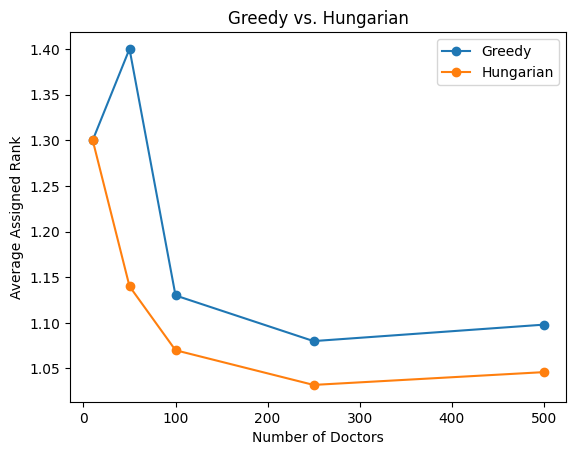

In [8]:
# Plot average assigned rank across problem sizes

for method in ["Greedy", "Hungarian"]:

    subset = results_df[
        results_df["Method"] == method
    ]

    plt.plot(
        subset["Doctors"],
        subset["Average Rank"],
        marker="o",
        label=method
    )


plt.xlabel("Number of Doctors")
plt.ylabel("Average Assigned Rank")
plt.title("Greedy vs. Hungarian")
plt.legend()
plt.show()

## References
- García, A. Greedy algorithms: a review and open problems. J Inequal Appl 2025, 11 (2025). https://doi.org/10.1186/s13660-025-03254-1
- Kuhn, H.W. (1955), The Hungarian method for the assignment problem. Naval Research Logistics, 2: 83-97. https://doi.org/10.1002/nav.3800020109